## **Downloading**

In [45]:
!pip install biopython pandas networkx matplotlib tqdm py4cytoscape python-louvain

In [3]:
!wget -O - https://ftp.ebi.ac.uk/pub/databases/metagenomics/peptide_database/current_release/mgy_proteins_1.fa.gz | gunzip | head -n 20000 > subset.fasta

--2026-03-12 13:15:16--  https://ftp.ebi.ac.uk/pub/databases/metagenomics/peptide_database/current_release/mgy_proteins_1.fa.gz
Resolving ftp.ebi.ac.uk (ftp.ebi.ac.uk)... 193.62.193.165
Connecting to ftp.ebi.ac.uk (ftp.ebi.ac.uk)|193.62.193.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11412619458 (11G) [application/x-gzip]
Saving to: ‘STDOUT’

-                     0%[                    ]   1.13M  2.46MB/s               
gzip: stdout: Broken pipe
-                     0%[                    ]   1.56M  3.34MB/s    in 0.5s    


Cannot write to ‘-’ (Success).


In [6]:
!grep -c ">" subset.fasta

10000


In [8]:
!head subset.fasta

>MGYP004668706029 FL=1
MNIVRDLAVILISAGVFTIISKALKQPLILGYILAGFLIGPNVTFFPGITNEATMHQWSEIGIIFLMFGLGLEFSFKKLLKVGGSAIVTAAVKFVGVFIIGFVTAQALSWSFMESVFLGGLLSMSSTMVVLKSYDDLGLKNKPYAGVVFGTLVVEDLIAILLMVLLSTMAVSQSFAGKELIMNIAKLVFFLILWFLVGIYVIPTLLKKAKEYLNDEILLIVSIGLCFGMVALATSVGFSSALGAFVMGSILAETSESEHIDHIVEPIKNLFGAIFFVSVGMMVAPSVIAEHWAMILLLSVIVIISHIIFAGAGIILTGKGLDNAVHTGFSLAQLGEFGFIIAGVGCTLGVMRDFIYPVIIAVSVITTFTTPFMIKLADPCYNLLNKRLPAKWIDRLAQMNDSGKQTAAEHNEWKTLLNAYFTRIVLYGVILIAIYIGSKLYLRPAVEKFSPELSVTIHKVIEVGITLAAMLPFLFGLGVHSGSISKSAPKLLKEKPSNIWPLMGLIFARSFLAVGIVLAVLSSYFHLAGWTVLAIFFAGIIFILFARRSIHKYSALEMRFLSNFNEKEENERRSKPVASSVSQKLADYDVHTETLTISQNSTYAGKALKDIPFRAETGANIIKITRGSMNMIVPSGDVSLFPGDQMLAVGTSAQLESLRNMMACAVAPEIQDSGNSFKIVPEALTEESFLTGKTLRGTNLRKYHCMVISVLRGSEFITNPEPDFRFQAGDTVWIAGNLAELETV
>MGYP000862152061 FL=0
LNGDQTNRERLQVLVDESATKDSNAKYYNADAEIQAVYDKAVEEAKATLAKENVTQAEVDAAKAKLQEAKDALNGVDTNKEALQNLADESNAKDSNAKYYNADADKQEAYNKAVEEAKAVLSKENVTQAEIDAAKAKLQEAKDALNGADTNKTELEKQVELKNSDEVTKDSKYYNASEESLLNYYNVVKKAEETLAKPNVTQDEVDKMV

In [10]:
!grep ">" subset.fasta | sed 's/>//' > protein_ids.txt

In [12]:
!wget -qO- https://ftp.ebi.ac.uk/pub/databases/metagenomics/peptide_database/current_release/mgy_biomes.tsv.gz \
| zcat | grep -F -f protein_ids.txt > metadata.tsv

In [13]:
!ls -lh metadata.tsv

-rw-r--r-- 1 root root 5.7K Mar 12 13:30 metadata.tsv


In [14]:
!head metadata.tsv

MGYP000225593703	2	root:Host-associated:Human:Digestive system
MGYP000225593703	5	root:Host-associated:Human:Digestive system:Hindgut
MGYP000225593703	12	root:Host-associated:Human:Digestive system:Large intestine
MGYP000225593703	68	root:Host-associated:Human:Digestive system:Large intestine:Fecal
MGYP000225593703	1	root:Host-associated:Mammals:Digestive system:Fecal
MGYP000225593703	9	root:Host-associated:Mammals:Digestive system:Large intestine:Fecal
MGYP000229914253	1	root:Host-associated:Human:Digestive system:Large intestine
MGYP000229914253	1	root:Mixed
MGYP000266133040	4	root:Host-associated:Human:Digestive system:Large intestine:Fecal
MGYP000266133040	1	root:Host-associated:Mammals:Digestive system:Large intestine:Fecal


In [15]:
!wc -l metadata.tsv

81 metadata.tsv


## **Processing**

In [17]:
from Bio import SeqIO

sequences = []

for record in SeqIO.parse("subset.fasta", "fasta"):
    
    sequences.append({
        "protein_id": record.id,
        "sequence": str(record.seq)
    })

print("Total proteins:", len(sequences))

Total proteins: 10000


In [18]:
import pandas as pd

metadata = pd.read_csv("metadata.tsv", sep="\t", header=None)
metadata.columns = ["protein_id", "count", "biome"]
print(metadata.head())

         protein_id  count                                              biome
0  MGYP000225593703      2        root:Host-associated:Human:Digestive system
1  MGYP000225593703      5  root:Host-associated:Human:Digestive system:Hi...
2  MGYP000225593703     12  root:Host-associated:Human:Digestive system:La...
3  MGYP000225593703     68  root:Host-associated:Human:Digestive system:La...
4  MGYP000225593703      1  root:Host-associated:Mammals:Digestive system:...


In [19]:
metadata_map = dict(
    zip(metadata.protein_id, metadata.biome)
)

for seq in sequences:
    seq["biome"] = metadata_map.get(seq["protein_id"], "unknown")

In [23]:
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

records = []

for seq in sequences:
    
    record = SeqRecord(
        Seq(seq["sequence"]),
        id=seq["protein_id"],
        description=""
    )

    records.append(record)

SeqIO.write(records, "proteins.fasta", "fasta")

10000

In [ ]:
!wget -qO- https://micromamba.snakepit.net/api/micromamba/linux-64/latest | tar -xvj bin/micromamba
!./bin/micromamba install -y -n base -c conda-forge -c bioconda mmseqs2

In [ ]:
!apt-get update
!apt-get install -y mmseqs2

In [ ]:
!mmseqs --help

In [37]:
import subprocess
import os
output_dir="/kaggle/working/output"
def run_mmseqs(input_fasta, output_dir):

    os.makedirs(output_dir, exist_ok=True)

    db = f"{output_dir}/proteinDB"
    result = f"{output_dir}/resultDB"
    tmp = f"{output_dir}/tmp"
    tsv = f"{output_dir}/similarity.tsv"

    print("Creating MMseqs database...")
    subprocess.run(["mmseqs", "createdb", input_fasta, db], check=True)

    print("Running similarity search...")
    subprocess.run([
        "mmseqs",
        "search",
        db,
        db,
        result,
        tmp,
        "--min-seq-id",
        "0.3",
        "-c",
        "0.8"
    ], check=True)

    print("Converting results to TSV...")
    subprocess.run([
        "mmseqs",
        "convertalis",
        db,
        db,
        result,
        tsv
    ], check=True)

    print("Done! Output file:", tsv)

In [38]:
run_mmseqs("proteins.fasta", "mmseqs_output")

Creating MMseqs database...
createdb proteins.fasta mmseqs_output/proteinDB 

MMseqs Version:       	13-45111+ds-2
Database type         	0
Shuffle input database	true
Createdb mode         	0
Write lookup file     	1
Offset of numeric ids 	0
Compressed            	0
Verbosity             	3

Converting sequences
[
Time for merging to proteinDB_h: 0h 0m 0s 3ms
Time for merging to proteinDB: 0h 0m 0s 7ms
Database type: Aminoacid
Time for processing: 0h 0m 0s 45ms
Running similarity search...
Create directory mmseqs_output/tmp
search mmseqs_output/proteinDB mmseqs_output/proteinDB mmseqs_output/resultDB mmseqs_output/tmp --min-seq-id 0.3 -c 0.8 

MMseqs Version:                        	13-45111+ds-2
Substitution matrix                    	nucl:nucleotide.out,aa:blosum62.out
Add backtrace                          	false
Alignment mode                         	2
Alignment mode                         	0
Allow wrapped scoring                  	false
E-value threshold                      	0

In [40]:
import pandas as pd
import networkx as nx

df = pd.read_csv("mmseqs_output/similarity.tsv", sep="\t", header=None)

df = df[[0,1,2]]
df.columns = ["query","target","identity"]

G = nx.Graph()

for _,row in df.iterrows():
    
    if row.identity >= 0.3:
        G.add_edge(row.query,row.target,weight=row.identity)

print("Nodes:",G.number_of_nodes())
print("Edges:",G.number_of_edges())

Nodes: 10000
Edges: 25245


In [41]:
for node in G.nodes():
    biome = metadata_map.get(node, "unknown")
    G.nodes[node]["biome"] = biome

In [43]:
print(G.nodes["MGYP000229914253"])

{'biome': 'root:Mixed'}


In [44]:
threshold = 0.4

edges_to_remove = [
    (u,v) for u,v,d in G.edges(data=True)
    if d["weight"] < threshold
]

G.remove_edges_from(edges_to_remove)

print("Nodes:",G.number_of_nodes())
print("Edges:",G.number_of_edges())

Nodes: 10000
Edges: 18644


In [46]:
import community as community_louvain

partition = community_louvain.best_partition(G)

In [47]:
for node,cluster in partition.items():
    G.nodes[node]["cluster"] = cluster

In [48]:
print("Communities:", len(set(partition.values())))

Communities: 6736


In [50]:
import pandas as pd

cluster_df = pd.DataFrame(list(partition.items()),
                          columns=["protein","cluster"])

print(cluster_df.cluster.value_counts().head())

cluster
423    69
94     67
245    53
10     51
13     46
Name: count, dtype: int64


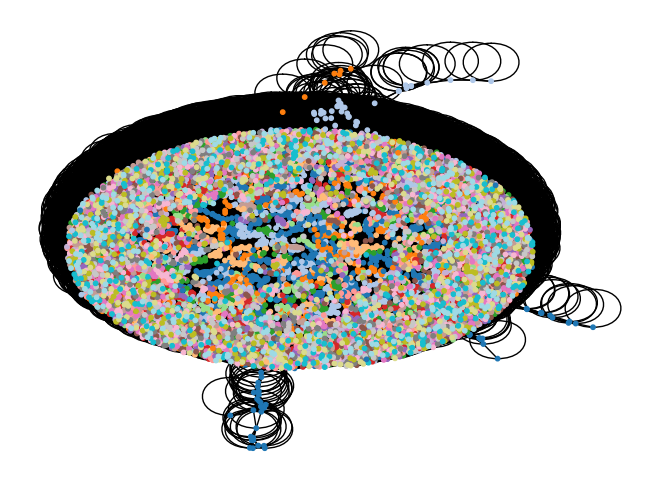

In [56]:
import matplotlib.pyplot as plt
import networkx as nx

pos = nx.spring_layout(G, k=0.15)

colors = [G.nodes[n]["cluster"] for n in G.nodes()]

nx.draw(
    G,
    pos,
    node_size=10,
    node_color=colors,
    cmap=plt.cm.tab20,
    with_labels=False
)

plt.show()

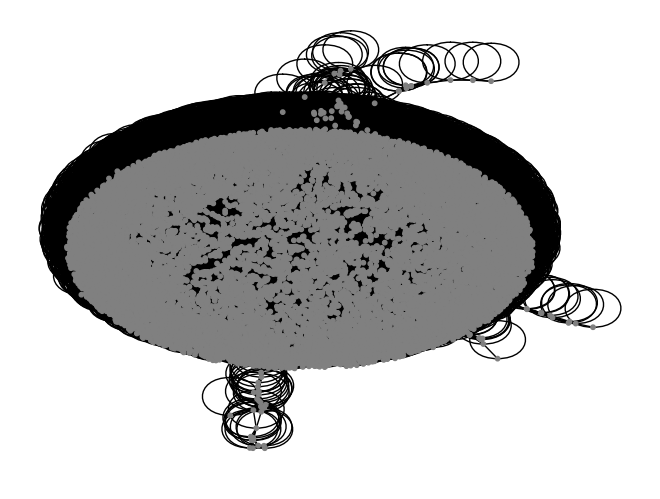

In [57]:
biome_colors = {
    "marine":"blue",
    "soil":"green",
    "gut":"red",
    "unknown":"gray"
}

colors = [
    biome_colors.get(G.nodes[n]["biome"],"gray")
    for n in G.nodes()
]

nx.draw(G,pos,node_color=colors,node_size=10)
plt.show()

In [58]:
nodes = []

for n,d in G.nodes(data=True):
    
    nodes.append({
        "protein":n,
        "biome":d["biome"],
        "cluster":d["cluster"]
    })

pd.DataFrame(nodes).to_csv("nodes.csv",index=False)

In [59]:
edges = []

for u,v,d in G.edges(data=True):
    
    edges.append({
        "source":u,
        "target":v,
        "weight":d["weight"]
    })

pd.DataFrame(edges).to_csv("edges.csv",index=False)